In [1]:
import numpy as np
import numpy.linalg as lg
import matplotlib.pyplot as plt
%matplotlib inline
import jax.numpy as jnp
from tools import calculate_coefs_for_trunk, calculate_coefs_for_trajectory

In [2]:
d = 64

In [3]:
l = 5
x = np.arange(d + 1).reshape(-1, 1)
cov = np.exp(- 0.5 * np.square((x - x.T)/l))
cov = 0.0625 * cov + np.ones_like(cov) * 100
noisy_cov = cov + np.eye(d + 1) * 0.01
transform_matrix = jnp.array((lg.solve(noisy_cov, cov[:, -1:])).T, jnp.float32)

In [4]:
log_discount = jnp.log(0.99 * 0.95)
weights = 0.99 / (1 - 0.99 * 0.95) * (1 - jnp.exp(log_discount * jnp.arange(d + 1)))
weights = weights * jnp.where(jnp.arange(d + 1) < d, 1 - 0.95, 1)
weights = weights - jnp.where(jnp.arange(d + 1) < d, 1.0, 0.0)

In [5]:
# weights = weights * jnp.where(jnp.arange(d + 1) < d, 1, 0) + transform_matrix.squeeze(0)[::-1] * weights[-1]
weights = weights * jnp.where(jnp.arange(d + 1) < d, 1, 0) + transform_matrix.squeeze(0) * weights[-1]

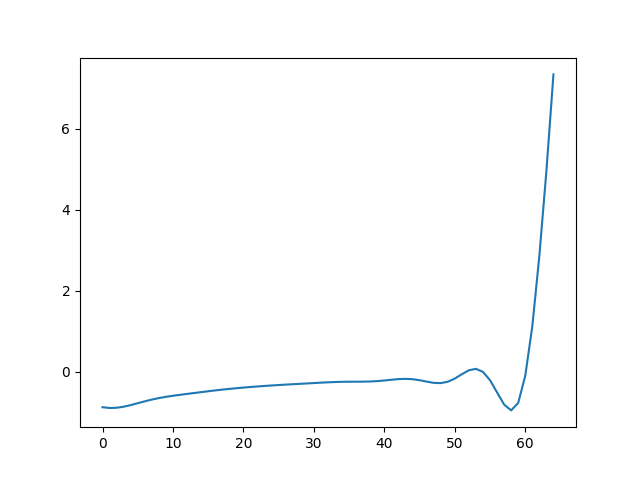

In [6]:
plt.plot(jnp.arange(d + 1), weights)
plt.show()

In [7]:
reward_weights = (1 - jnp.exp(log_discount * jnp.arange(d) + log_discount)) / (1 - 0.99 * 0.95)

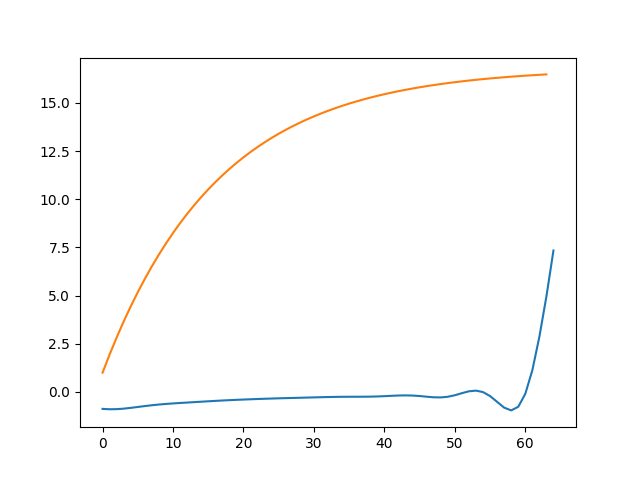

In [8]:
plt.plot(jnp.arange(d), reward_weights)
plt.show()

In [12]:
d = 64
# reward_coefs, v_coefs = calculate_coefs_for_trunk(d, 0, 64, 10, 0.99, 0.95)
reward_coefs, v_coefs = calculate_coefs_for_trajectory(d, 0, 64, 5, 0.99, 0.95)

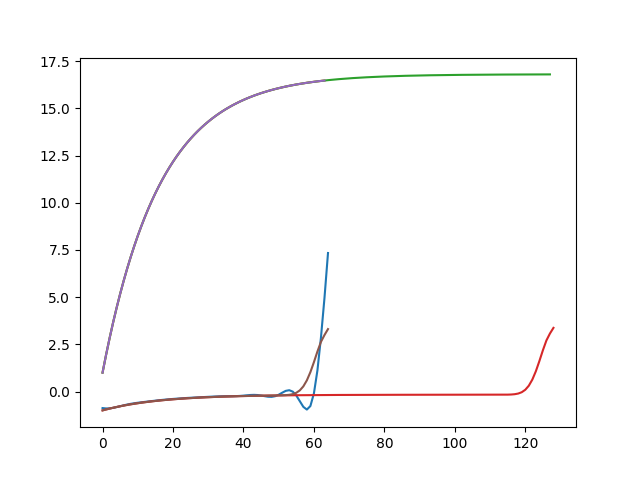

In [13]:
plt.plot(jnp.arange(d), reward_coefs.squeeze(-1))
plt.plot(jnp.arange(d + 1), v_coefs.squeeze(-1))
plt.show()

In [15]:
print(weights - v_coefs.squeeze(-1))

[ 1.2280011e-01  5.4116607e-02  1.3151228e-02 -4.5963526e-03
 -5.8702826e-03  1.9595623e-03  1.2433171e-02  2.1060944e-02
  2.5698960e-02  2.6265979e-02  2.4016559e-02  2.0679474e-02
  1.7741203e-02  1.6043127e-02  1.5721679e-02  1.6402483e-02
  1.7504454e-02  1.8515050e-02  1.9149214e-02  1.9369811e-02
  1.9303918e-02  1.9117653e-02  1.8913746e-02  1.8693268e-02
  1.8390268e-02  1.7955571e-02  1.7443269e-02  1.7049462e-02
  1.7066687e-02  1.7751426e-02  1.9144624e-02  2.0924151e-02
  2.2383243e-02  2.2606492e-02  2.0844907e-02  1.6992420e-02
  1.1966050e-02  7.7469945e-03  6.8938881e-03  1.1518002e-02
  2.1979406e-02  3.5833851e-02  4.7693178e-02  5.0520778e-02
  3.8406491e-02  1.0131225e-02 -2.7909473e-02 -6.1223924e-02
 -7.0620671e-02 -3.9662257e-02  3.5558015e-02  1.3793376e-01
  2.2667041e-01  2.4400194e-01  1.3195717e-01 -1.4427808e-01
 -5.7348669e-01 -1.0844846e+00 -1.5478122e+00 -1.7954624e+00
 -1.6559584e+00 -9.9776876e-01  2.2891188e-01  1.9635174e+00
  4.0305386e+00]
